## **Data Understanding and Preparation**

Import the necessary libraries:
- pandas to open, read, and modify the CSV dataset
- matplotlib.pyplot as plt to visualize the data into charts
- plotly.express to visualize the data into a geomap chart

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.express as px

Download the data and open the CSV file. Then, read the top 10 rows to get an overview of the dataset.

In [2]:
df = pd.read_csv('./Dataset/customers-100000.csv')
df.head(10)

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,Sanchez-Fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/
1,2,b687FfC4F1600eC,Marie,Malone,Mckay PLC,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,Marks and Sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"Kirby, Vaughn and Sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,Lester-Manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/
5,6,75bEe1B33E517AF,Frank,Villarreal,"Craig, Dennis and Maddox",Reidtown,Panama,+1-165-340-7100x44099,(847)867-2795x043,gmurillo@perez.com,2022-01-13,https://patel.org/
6,7,CB8b29B8Fbbbe58,Rickey,Fox,"Benson, Gray and Fitzpatrick",Mcintoshberg,United States of America,426.446.3838,437.476.4705,melissabenitez@le.info,2021-11-05,http://www.irwin-donaldson.com/
7,8,56b3cEA1E6A49F1,Barry,Ware,Glenn Ltd,Lake Pedrofort,American Samoa,101-419-0208x043,931.542.3115x98926,brent60@lopez.com,2022-05-12,https://www.bean.biz/
8,9,f9443f5f6AF0Da0,Carl,Mcdowell,Davila-Leach,Petersbury,Saint Vincent and the Grenadines,+1-740-392-0511,+1-218-891-5403x7270,toddharris@lowery-rosario.biz,2022-05-28,https://www.burnett.com/
9,10,C99b63E0d92C565,Pam,Dalton,Mckenzie Ltd,Hillside,Tanzania,0389689232,344-952-1181x6911,carolbanks@vang-stafford.com,2022-03-04,http://www.maxwell-bradford.com/


Based on the data information, we can see that this dataset has 12 columns and is only around 9.2+ MB, which is relatively small. Most of the datatypes (11 columns) are object types (similar to strings), and only the Index column has an integer datatype.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Index              100000 non-null  int64 
 1   Customer Id        100000 non-null  object
 2   First Name         100000 non-null  object
 3   Last Name          100000 non-null  object
 4   Company            100000 non-null  object
 5   City               100000 non-null  object
 6   Country            100000 non-null  object
 7   Phone 1            100000 non-null  object
 8   Phone 2            100000 non-null  object
 9   Email              100000 non-null  object
 10  Subscription Date  100000 non-null  object
 11  Website            100000 non-null  object
dtypes: int64(1), object(11)
memory usage: 9.2+ MB


In [4]:
print(df.shape)

(100000, 12)


From the analysis of unique values using df.nunique(), we observe that several columns such as Index, Customer Id, Phone 1, and Phone 2 contain almost entirely unique values, indicating that they function as identifiers rather than analytical features.

Additionally, Company, City, and Website exhibit high cardinality, which suggests that they require aggregation before being used in analysis.

Meanwhile, Country and Subscription Date provide more meaningful categorical and temporal structures suitable for segmentation and trend analysis.

In [5]:
print(df.nunique())

Index                100000
Customer Id          100000
First Name              690
Last Name              1000
Company               71994
City                  49154
Country                 243
Phone 1              100000
Phone 2              100000
Email                 99995
Subscription Date       880
Website               50471
dtype: int64


Before extracting insights, we need to preprocess the data. First, we check for null or empty values.

As we can see, there are no missing values identified in the dataset. So, we can assume that the data is already clean from null values.

In [6]:
df.isnull().sum()

Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

In [7]:
df.isna().sum()

Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

Next, we check for duplicated data, and none are found. This means the dataset is already free from duplicate records.

In [8]:
df.duplicated().sum()

0

However, empty values are not always represented as "NA", "N/A", or "None"; they can also appear as blank spaces such as " ". We check this further for mitigation purposes, and the data is also clean.

In [9]:
(df == " ").sum()

Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64

After further analysis, the Company column is one of the features to be visualized. We check whether the string format is consistent (e.g., lowercase format). After reviewing the data, we find that company names are already consistent, so no transformation is needed.

In [10]:
df['Company'].str.lower().value_counts().head(10)

Company
wilkerson ltd       17
campbell ltd        17
acosta ltd          16
booker and sons     16
mckenzie plc        15
mccarty and sons    15
gregory group       15
farmer ltd          14
riggs plc           14
gomez inc           14
Name: count, dtype: int64

In [11]:
company_before = df['Company'].copy()
df['Company'] = df['Company'].str.lower()

In [12]:
before_unique = company_before.nunique()
after_unique = df['Company'].nunique()

print("Before:", before_unique)
print("After:", after_unique)
print("Merged:", before_unique - after_unique)

Before: 71994
After: 71994
Merged: 0


## **1st Insight: Subscription Trends by Year**

This code is used to convert the Subscription Date column into a datetime format so that we can extract the year and analyze trends over time.

In [13]:
df['Subscription Date'] = pd.to_datetime(df['Subscription Date'])

df['Year'] = df['Subscription Date'].dt.year
df.head(5)

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Year
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,sanchez-fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/,2021
1,2,b687FfC4F1600eC,Marie,Malone,mckay plc,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/,2021
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,marks and sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/,2021
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"kirby, vaughn and sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/,2020
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,lester-manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/,2020


There are three unique categories in the Year column, ranging from 2020 to 2022.

In [14]:
df['Year'].value_counts()

Year
2020    41898
2021    41211
2022    16891
Name: count, dtype: int64

We then initialize a color mapping for each year.

In [15]:
colors = {
    '2020': 'gray',
    '2021': 'steelblue',
    '2022': 'orange'
}

Next, we create a bar chart to visualize the total number of subscriptions per year. From the chart, we observe a downward trend from 2020 to 2022. A slight decrease occurred from 2020 to 2021, followed by a significant drop in 2022. This indicates that 2020 had the highest subscription activity, while 2022 recorded the lowest, suggesting a decline in retention over time.

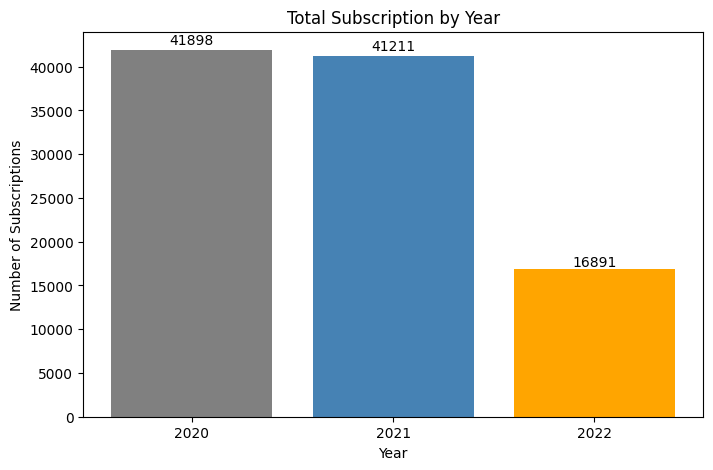

In [16]:
yearly_sub = df['Year'].value_counts().sort_index()
plt.figure(figsize=(8,5))

plt.bar(
    yearly_sub.index.astype(str),
    yearly_sub.values,
    color=[colors[str(year)] for year in yearly_sub.index]
)

plt.title('Total Subscription by Year')
plt.xlabel('Year')
plt.ylabel('Number of Subscriptions')
for i, v in enumerate(yearly_sub.values):
    plt.text(i, v + (v*0.015), str(v), ha='center')

plt.show()

For a deeper understanding, we analyze monthly trends. In 2020, the peak subscription occurred in December (3616), while the lowest was in February (3271). In 2021, the peak occurred in January (3580), and the lowest again in February (3106). In 2022, the lowest was also in February (3178), followed by a peak in March (3564). Notably, no month across all years exceeded the 2020 peak, and February consistently recorded the lowest subscription values.

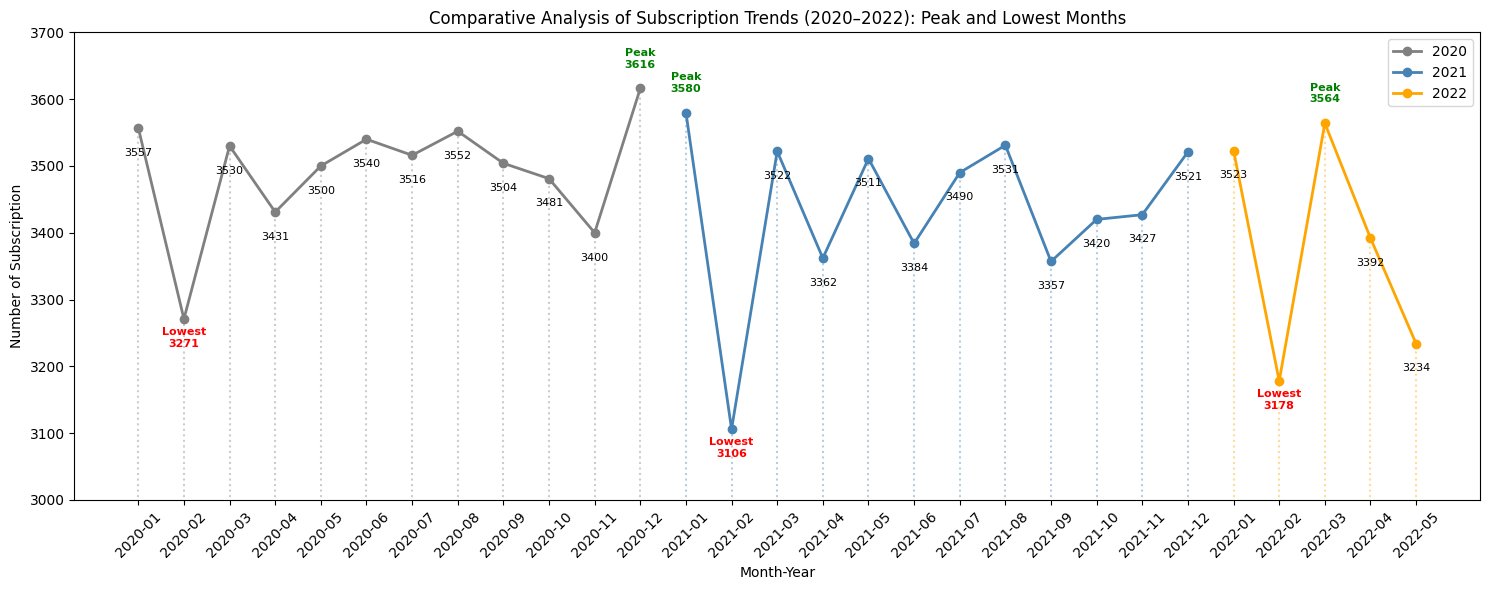

In [17]:
monthly_sub = df.groupby(df['Subscription Date'].dt.to_period('M')).size()

plt.figure(figsize=(15,6))

for year in ['2020','2021','2022']:
    yearly_data = monthly_sub[monthly_sub.index.year == int(year)]
    plt.plot(
    yearly_data.index.astype(str),
    yearly_data.values,
    marker='o',
    linewidth=2,
    label=year,
    color=colors[year]
)

    peak_month = yearly_data.idxmax()
    peak_value = yearly_data.max()
    low_month = yearly_data.idxmin()
    low_value = yearly_data.min()

    for i, (month, value) in enumerate(yearly_data.items()):
        label_color = 'black'
        font_weight = 'normal'
        text = str(value)

        # Peak
        if month == peak_month:
            label_color = 'green'
            font_weight = 'bold'
            text = f'Peak\n{value}'

        # Lowest
        elif month == low_month:
            label_color = 'red'
            font_weight = 'bold'
            text = f'Lowest\n{value}'

        plt.annotate(text, xy=(str(month), value), xytext=(0, -20 if month != peak_month else 15), textcoords='offset points', ha='center', fontsize=8, color=label_color, fontweight=font_weight)
        plt.vlines(x=str(month), ymin=0, ymax=value, linestyles='dotted', alpha=0.4,color=colors[year]
        )

plt.title('Comparative Analysis of Subscription Trends (2020–2022): Peak and Lowest Months')
plt.xlabel('Month-Year')
plt.ylabel('Number of Subscription')
plt.ylim(3000,3700)

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## **2nd Insight: Global Subscription Distribution by Country (2020–2022)**

After visualizing the Country column, we identify the countries with the highest number of subscriptions. Congo (835 subscriptions) and Korea (820 subscriptions) rank at the top. This can be observed through darker shading in the geomap, indicating higher subscription density within a total of approximately 100,000 subscribers.

In [18]:
country_sub = df['Country'].value_counts().reset_index()
country_sub.columns = ['Country', 'Count']
country_sub['Percentage'] = (country_sub['Count'] / country_sub['Count'].sum() * 100).round(2)
country_sub['Rank'] = country_sub['Count'].rank(method='dense', ascending=False).astype(int)

fig = px.choropleth(
    country_sub,
    locations='Country',
    locationmode='country names',
    color='Count',
    hover_name='Country',
    hover_data={
        'Count': True,
        'Percentage': True,
        'Rank': True
    },
    color_continuous_scale='Blues',
    title='Global Subscription Distribution by Country (2020–2022)'
)

fig.add_annotation(
    text=f"Total Subscribers: {country_sub['Count'].sum():,}",
    x=0.5,
    y=-0.1,
    showarrow=False,
    xref="paper",
    yref="paper"
)

fig.show()

From the top 5 countries, we find:
- Congo (835)
- Korea (820)
- Saudi Arabia (463)
- Pitcairn Islands (456)
- Saint Martin (453)

In [19]:
top5 = country_sub.head(5)
print(top5)

            Country  Count  Percentage  Rank
0             Congo    835        0.84     1
1             Korea    820        0.82     2
2      Saudi Arabia    463        0.46     3
3  Pitcairn Islands    456        0.46     4
4      Saint Martin    453        0.45     5


The bottom 5 countries are:
- Moldova (371)
- Jordan (365)
- Saint Lucia (365)
- Slovenia (361)
- Greece (359)

In [20]:
top5_low = country_sub.tail(5)
print(top5_low)

         Country  Count  Percentage  Rank
238      Moldova    371        0.37    74
239       Jordan    365        0.36    75
240  Saint Lucia    365        0.36    75
241     Slovenia    361        0.36    76
242       Greece    359        0.36    77


## **3rd Insight: Top Companies by Subscription Count**

In [21]:
top_company = df['Company'].value_counts().head(10)
print(top_company)

Company
wilkerson ltd       17
campbell ltd        17
acosta ltd          16
booker and sons     16
mckenzie plc        15
mccarty and sons    15
gregory group       15
farmer ltd          14
riggs plc           14
gomez inc           14
Name: count, dtype: int64


After analyzing companies with the highest subscriptions, we visualize them using a bar chart. Interestingly, the companies with the highest subscription counts do not come from the top-ranking countries. For example, Wilkerson is from Bermuda, Campbell from the Bahamas, Acosta from Austria, Booker and SOS from Afghanistan, and others.

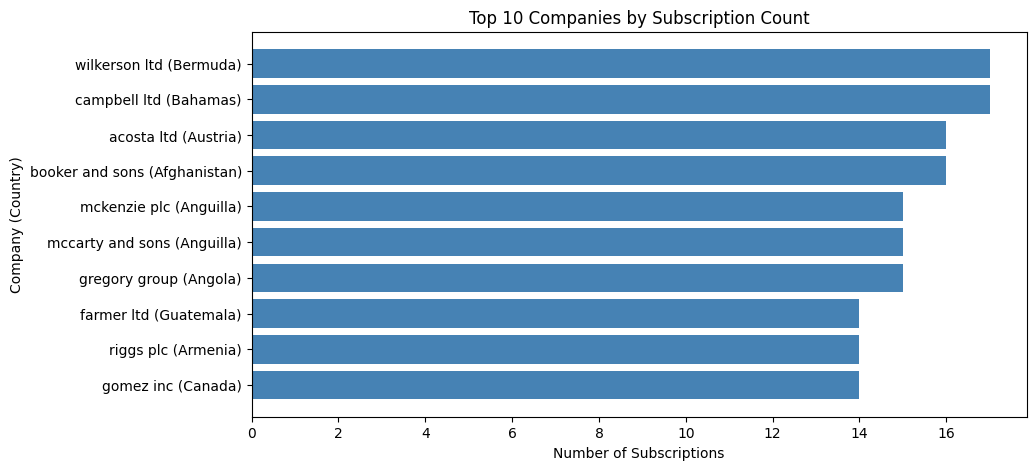

In [22]:
company_country = df.groupby('Company')['Country'].agg(lambda x: x.mode()[0])
top_company_df = top_company.reset_index()
top_company_df.columns = ['Company', 'Count']
top_company_df['Country'] = top_company_df['Company'].map(company_country)
top_company_df['Label'] = top_company_df['Company'] + ' (' + top_company_df['Country'] + ')'

plt.figure(figsize=(10,5))

plt.barh(
    top_company_df['Label'],
    top_company_df['Count'],
    color='steelblue'
)

plt.title('Top 10 Companies by Subscription Count')
plt.xlabel('Number of Subscriptions')
plt.ylabel('Company (Country)')

plt.gca().invert_yaxis()
plt.show()

When checking country rankings, Bermuda, Bahamas, Austria, Afghanistan, and Anguilla are not even in the top 10 or top 20. Their rankings are approximately:
- Bahamas: 27th
- Afghanistan: 31st
- Austria: 39th
- Bermuda: 48th
- Anguilla: 68th

In [23]:
country_sub[
    country_sub['Country'].isin(['Bermuda', 'Bahamas', 'Austria', 'Afghanistan', 'Anguilla'])
]

,Country,Count,Percentage,Rank
66,Bahamas,421,0.42,27
80,Afghanistan,417,0.42,31
123,Austria,409,0.41,39
161,Bermuda,400,0.40,48
219,Anguilla,379,0.38,68


This shows that high country subscription rankings do not necessarily translate into strong company-level retention.

Wilkerson shows a consistent subscription trend from 2020 to 2022, indicating strong year-over-year retention. This suggests that customers are highly engaged and likely to renew their subscriptions.

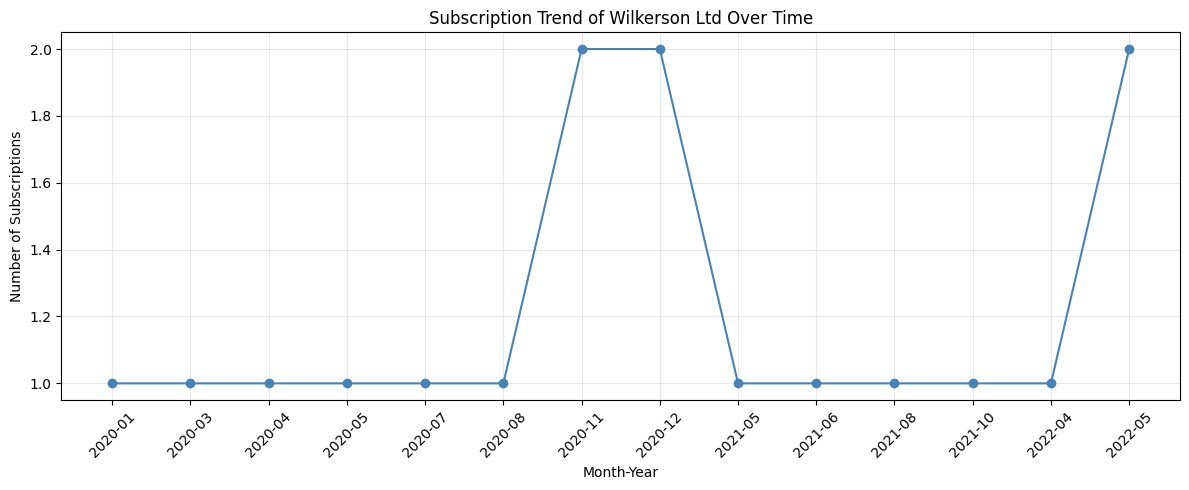

In [24]:
wilkerson_df = df[df['Company'] == 'wilkerson ltd']
wilkerson_trend = wilkerson_df.groupby(
    wilkerson_df['Subscription Date'].dt.to_period('M')
).size()
plt.figure(figsize=(12,5))

plt.plot(
    wilkerson_trend.index.astype(str),
    wilkerson_trend.values,
    marker='o',
    color='steelblue'
)

plt.title('Subscription Trend of Wilkerson Ltd Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Subscriptions')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Similarly, Campbell also shows a stable upward trend, reflecting strong retention and consistent customer behavior. These companies indicate stability in subscription patterns, suggesting opportunities for maintaining and increasing retention.

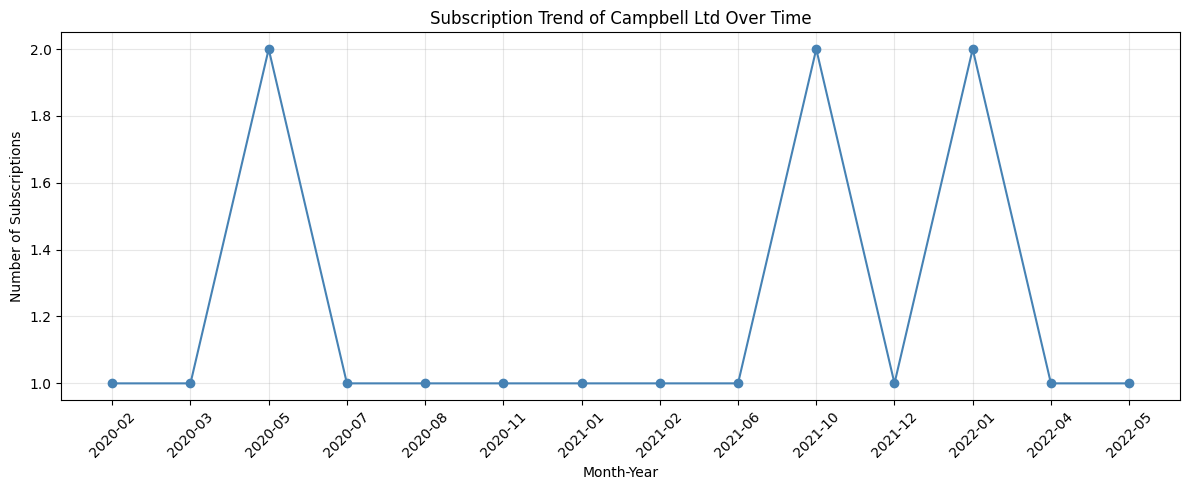

In [25]:
campbell_df = df[df['Company'] == 'campbell ltd']
campbell_trend = campbell_df.groupby(
    campbell_df['Subscription Date'].dt.to_period('M')
).size()
plt.figure(figsize=(12,5))

plt.plot(
    campbell_trend.index.astype(str),
    campbell_trend.values,
    marker='o',
    color='steelblue'
)

plt.title('Subscription Trend of Campbell Ltd Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Subscriptions')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In contrast, Congo and Korea—despite being top-ranked countries—show weaker retention patterns. Although they successfully acquire new customers, they struggle to maintain long-term engagement. This presents two perspectives: one focused on acquisition strength (Congo and Korea) and another focused on retention strength (companies like Wilkerson and Campbell).

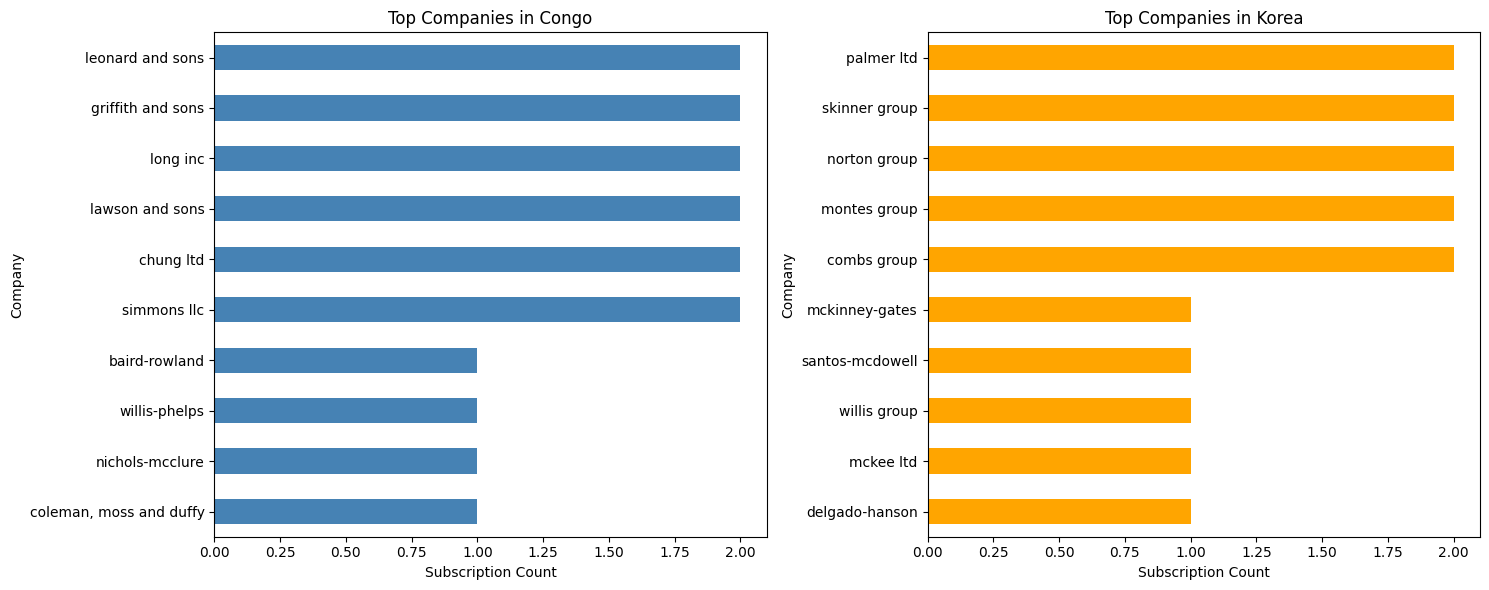

In [26]:
congo_company = df[df['Country']=='Congo']['Company'].value_counts().head(10)
korea_company = df[df['Country']=='Korea']['Company'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# LEFT = Congo
congo_company.plot(
    kind='barh',
    ax=axes[0],
    color='steelblue'
)
axes[0].invert_yaxis()
axes[0].set_title('Top Companies in Congo')
axes[0].set_xlabel('Subscription Count')

# RIGHT = Korea
korea_company.plot(
    kind='barh',
    ax=axes[1],
    color='orange'
)
axes[1].invert_yaxis()
axes[1].set_title('Top Companies in Korea')
axes[1].set_xlabel('Subscription Count')

plt.tight_layout()
plt.show()

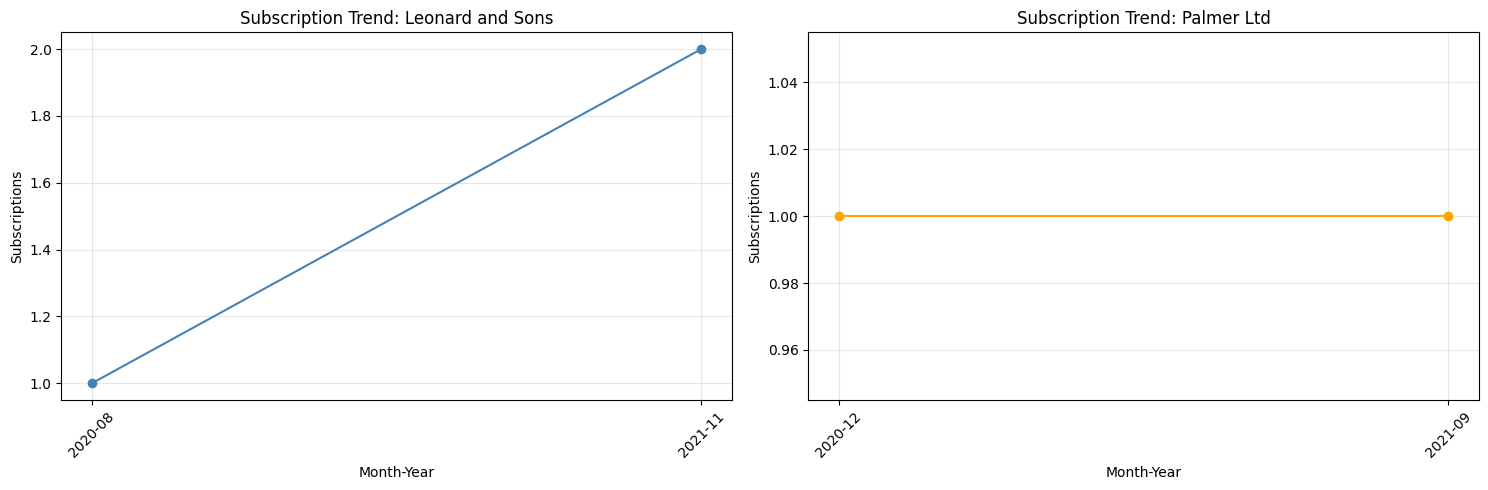

In [27]:
leonard_df = df[df['Company'] == 'leonard and sons']
palmer_df = df[
    (df['Country'] == 'Korea') &
    (df['Company'] == 'palmer ltd')
]

leonard_trend = leonard_df.groupby(
    leonard_df['Subscription Date'].dt.to_period('M')
).size()

palmer_trend = palmer_df.groupby(
    palmer_df['Subscription Date'].dt.to_period('M')
).size()

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Leonard
axes[0].plot(
    leonard_trend.index.astype(str),
    leonard_trend.values,
    marker='o',
    color='steelblue'
)
axes[0].set_title('Subscription Trend: Leonard and Sons')
axes[0].set_xlabel('Month-Year')
axes[0].set_ylabel('Subscriptions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Palmer
axes[1].plot(
    palmer_trend.index.astype(str),
    palmer_trend.values,
    marker='o',
    color='orange'
)
axes[1].set_title('Subscription Trend: Palmer Ltd')
axes[1].set_xlabel('Month-Year')
axes[1].set_ylabel('Subscriptions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **4th Insight: Comparative Analysis Between Domain Types**

In [28]:
df['Email Domain'] = df['Email'].str.split('@').str[1]
df['Email Domain'].value_counts().head(20)

Email Domain
mckee.com          59
pugh.com           59
terrell.com        57
lawrence.com       57
gaines.com         56
romero.com         56
delgado.com        56
glass.com          55
jacobson.com       55
fitzpatrick.com    55
pratt.com          54
burke.com          54
kirk.com           54
reese.com          54
cohen.com          54
rowe.com           54
hayes.com          54
thomas.com         54
short.com          54
hogan.com          53
Name: count, dtype: int64

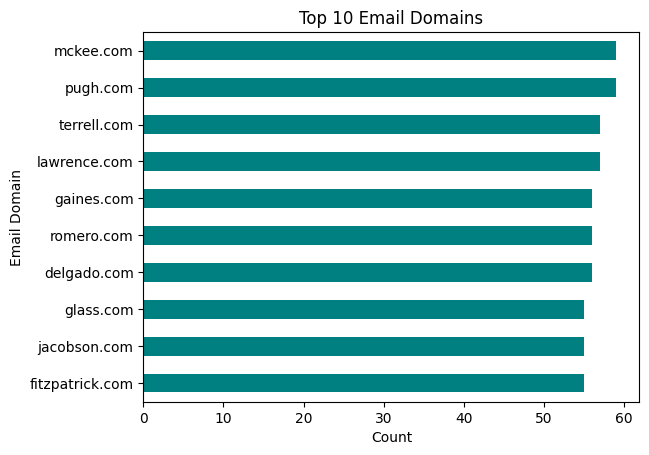

In [29]:
top_domain = df['Email Domain'].value_counts().head(10)

top_domain.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()

plt.title('Top 10 Email Domains')
plt.xlabel('Count')

plt.show()

In [30]:
personal_domains = [
    'gmail.com',
    'yahoo.com',
    'hotmail.com',
    'outlook.com',
    'icloud.com',
    'aol.com',
    'live.com',
    'msn.com'
]

df['Email Domain'] = df['Email'].str.split('@').str[1]
personal_email_df = df[
    df['Email Domain'].isin(personal_domains)
]
print(len(personal_email_df))

0


In [31]:
df['Email Type'] = df['Email Domain'].apply(
    lambda x: 'Personal' if x in personal_domains else 'Business'
)

print(df['Email Type'].value_counts())

Email Type
Business    100000
Name: count, dtype: int64


By analyzing email domains used for subscriptions, we observe that most customers use business domains rather than personal email domains. No significant usage of personal domains is found in the dataset.

## **5th Insight: Anomaly Detection Within Customer's Phone Numbers**

Finally, we analyze potential CSR-related issues by examining phone number lengths (Phone 1 and Phone 2). Most customer phone numbers range between 10 to 22 digits.

In [32]:
df['Phone Length'] = df['Phone 1'].str.len()

df['Phone Length'].describe()

count    100000.000000
mean         16.158370
std           3.491039
min          10.000000
25%          13.000000
50%          17.000000
75%          19.000000
max          22.000000
Name: Phone Length, dtype: float64

We then identify conditions that may indicate anomalies in phone numbers, where certain formats appear invalid or inconsistent.

In [33]:
format_summary = {
    'Contains Dash (-)': df['Phone 1'].str.contains('-').sum(),
    'Contains Dot (.)': df['Phone 1'].str.contains('\.').sum(),
    'Contains Parentheses ()': df['Phone 1'].str.contains('\(').sum(),
    'Contains Extension (x)': df['Phone 1'].str.contains('x').sum(),
    'Starts with +': df['Phone 1'].str.startswith('+').sum()
}

print(format_summary)

<>:3: SyntaxWarning:

invalid escape sequence '\.'

<>:4: SyntaxWarning:

invalid escape sequence '\('

<>:3: SyntaxWarning:

invalid escape sequence '\.'

<>:4: SyntaxWarning:

invalid escape sequence '\('

C:\Users\Verren Angelina S\AppData\Local\Temp\ipykernel_18484\3153247220.py:3: SyntaxWarning:

invalid escape sequence '\.'

C:\Users\Verren Angelina S\AppData\Local\Temp\ipykernel_18484\3153247220.py:4: SyntaxWarning:

invalid escape sequence '\('



{'Contains Dash (-)': 72072, 'Contains Dot (.)': 20035, 'Contains Parentheses ()': 20202, 'Contains Extension (x)': 59954, 'Starts with +': 15951}


After analyzing anomaly detection results, many numbers are flagged as anomalies due to incorrect or unusual formatting.

In [34]:
df['Phone Length'] = df['Phone 1'].str.len()

df['Anomaly Score'] = (
    (~df['Phone 1'].str.startswith('+')).astype(int) * 1 +
    (df['Phone 1'].str.contains('x', na=False)).astype(int) * 1 +
    (df['Phone Length'] < 12).astype(int) * 2 +
    (df['Phone Length'] > 20).astype(int) * 2 +
    (df['Phone 1'].str.count(r'\d') < 8).astype(int) * 2
)

top_anomalies = df.sort_values('Anomaly Score', ascending=False).head(10)
top_anomalies[['Phone 1', 'Country', 'Company', 'Phone Length', 'Anomaly Score']]

,Phone 1,Country,Company,Phone Length,Anomaly Score
13906,001-023-991-9527x3085,Macao,ayers-preston,21,4
13576,001-846-528-5057x88684,Malawi,shah-huber,22,4
13343,001-472-523-4374x0305,El Salvador,lynch and sons,21,4
82054,001-213-760-9316x65538,Afghanistan,hayden group,22,4
35608,001-613-302-9703x7368,Cocos (Keeling) Islands,morton-kemp,21,4
82037,001-455-484-1792x84935,Djibouti,jefferson-lutz,22,4
82036,001-164-734-7410x4598,Nigeria,briggs inc,21,4
82026,001-241-938-7536x5862,Pakistan,"gregory, castillo and yoder",21,4
82023,001-481-939-3582x6845,Paraguay,vargas-pierce,21,4
35604,001-544-012-4221x8107,Jersey,oconnor ltd,21,4


In [35]:
df['Phone Length 2'] = df['Phone 2'].str.len()

df['Anomaly Score 2'] = (
    (~df['Phone 2'].str.startswith('+')).astype(int) * 1 +
    (df['Phone 2'].str.contains('x', na=False)).astype(int) * 1 +
    (df['Phone Length 2'] < 12).astype(int) * 2 +
    (df['Phone Length 2'] > 20).astype(int) * 2 +
    (df['Phone 2'].str.count(r'\d') < 8).astype(int) * 2
)

top_anomalies = df.sort_values('Anomaly Score 2', ascending=False).head(10)
top_anomalies[['Phone 2', 'Country', 'Company', 'Phone Length 2', 'Anomaly Score 2']]

,Phone 2,Country,Company,Phone Length 2,Anomaly Score 2
4926,001-563-805-8316x7474,Christmas Island,patterson group,21,4
31317,001-358-707-1289x19176,Guinea-Bissau,"paul, romero and webster",22,4
34056,001-950-514-2361x54935,Philippines,"jensen, tanner and kelley",22,4
21788,001-853-170-4693x98580,Saint Pierre and Miquelon,"zimmerman, mayer and briggs",22,4
71067,001-263-377-8514x9945,Heard Island and McDonald Islands,andersen group,21,4
58468,001-638-961-4057x6614,Malaysia,"mahoney, juarez and mathis",21,4
71069,001-755-099-4649x28915,Paraguay,knox-young,22,4
91792,001-883-176-2328x5328,Egypt,baldwin-huff,21,4
21783,001-541-075-6863x1251,Chad,dougherty and sons,21,4
6235,001-090-184-4119x8457,Chile,"fowler, baxter and padilla",21,4


In [36]:
target_countries = ['Congo', 'Korea']

df_target = df[df['Country'].isin(target_countries)]

anomaly_summary = df_target.groupby('Country').agg(
    Phone1_Anomaly=('Anomaly Score', lambda x: (x > 0).sum()),
    Phone2_Anomaly=('Anomaly Score 2', lambda x: (x > 0).sum()),
    Total_Records=('Country', 'count')
).reset_index()

anomaly_summary

,Country,Phone1_Anomaly,Phone2_Anomaly,Total_Records
0,Congo,802,808,835
1,Korea,788,791,820


In [37]:
anomaly_summary['Phone1_Anomaly_%'] = (
    anomaly_summary['Phone1_Anomaly'] / anomaly_summary['Total_Records'] * 100
).round(2)

anomaly_summary['Phone2_Anomaly_%'] = (
    anomaly_summary['Phone2_Anomaly'] / anomaly_summary['Total_Records'] * 100
).round(2)

anomaly_summary

,Country,Phone1_Anomaly,Phone2_Anomaly,Total_Records,Phone1_Anomaly_%,Phone2_Anomaly_%
0,Congo,802,808,835,96.05,96.77
1,Korea,788,791,820,96.10,96.46


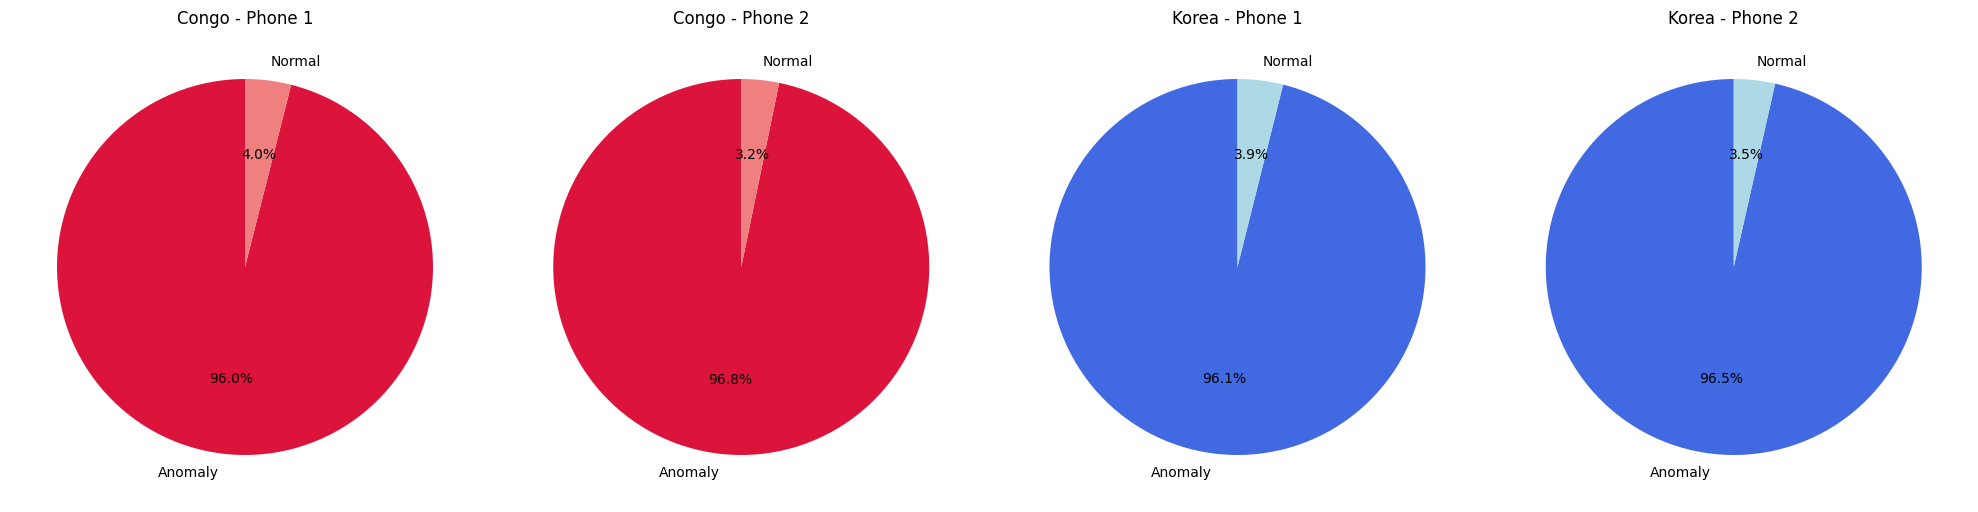

In [38]:
import matplotlib.pyplot as plt

data = {
    "Congo - Phone 1": (802, 835 - 802),
    "Congo - Phone 2": (808, 835 - 808),
    "Korea - Phone 1": (788, 820 - 788),
    "Korea - Phone 2": (791, 820 - 791),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, (anomaly, normal)) in zip(axes, data.items()):
    
    if "Congo" in title:
        colors = ["crimson", "lightcoral"]   # theme Congo
    else:
        colors = ["royalblue", "lightblue"]  # theme Korea

    ax.pie(
        [anomaly, normal],
        labels=["Anomaly", "Normal"],
        autopct="%1.1f%%",
        startangle=90,
        colors=colors
    )
    
    ax.set_title(title)

plt.tight_layout()
plt.show()

For example, in Congo and Korea, more than 96% of phone numbers are classified as anomalies. This could be a primary reason why agents or staff face difficulties in maintaining retention, as they may not be able to reliably contact customers for follow-ups.

The dataset reveals a pattern of strong customer acquisition but weak retention, combined with significant data quality issues in contact information. While certain countries generate high subscription volumes, long-term engagement appears to be driven more by company-level behavior. Additionally, inconsistent phone data may be limiting effective customer communication and retention strategies.
